# 13 — Black-Scholes Straddle Application

A simple application layer built purely on the **Black-Scholes analytic model**
(predictions in `data/predictions/SPY_model1.parquet`).

**Idea.** The model outputs 5 quantiles of the end-of-day close for each intraday
snapshot. The *predicted range* `q90_close - q10_close` measures how much the model
thinks the price could move. If that range exceeds a **threshold**, we predict a
heavy move and open a 0DTE position at the **ask**.

**Two knobs decide the trade:**
1. `RANGE_THRESHOLD` — *whether* to trade (only when the predicted range is large).
2. `MOMENTUM_N` — *which legs* to buy. If the underlying moved the same direction
   for the last `MOMENTUM_N` consecutive 15-min intervals we buy a single leg
   (all up → **call**, all down → **put**); otherwise we fall back to the full
   **straddle** (ATM call + ATM put). `MOMENTUM_N = 0` disables the rule.

Payoff at expiration:

    straddle : |close - strike| - (call_ask + put_ask)
    call     : max(close - strike, 0) - call_ask
    put      : max(strike - close, 0) - put_ask

Outputs:
1. A per-decision results table.
2. A visualization of **each day's PnL**.
3. A separate visualization of the **cumulative total PnL**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# CONFIG  --  the range threshold is the main knob, change it freely
# ----------------------------------------------------------------------
RANGE_THRESHOLD = 8.0        # dollars; trade only when q90_close - q10_close > this
CONTRACT_MULTIPLIER = 100    # 1 option contract controls 100 shares

# Directional rule: how many consecutive prior 15-min intervals must all move
# the SAME way to buy a single leg instead of a straddle.
#   MOMENTUM_N = 2  -> both t-2->t-1 and t-1->t must agree (stricter as N grows)
#   MOMENTUM_N = 0  -> rule disabled, always buy the straddle
MOMENTUM_N = 2
MOMENTUM_FALLBACK = "straddle"   # when the intervals disagree: "straddle" or "skip"

PRED_PATH = "../data/predictions/SPY_model1.parquet"
OPT_PATH  = "../data/processed/spy_processed.parquet"


In [2]:
# ----------------------------------------------------------------------
# Load data
# ----------------------------------------------------------------------
pred = pd.read_parquet(PRED_PATH).sort_values("timestamp").reset_index(drop=True)
opt  = pd.read_parquet(OPT_PATH)

pred["date"] = pred["timestamp"].dt.date
opt["date"]  = opt["timestamp"].dt.date
opt["exp_date"] = pd.to_datetime(opt["expiration"]).dt.date

# predicted move range = spread between the outer quantiles of the close
pred["pred_range"] = pred["q90_close"] - pred["q10_close"]

print(f"predictions : {len(pred):>7} snapshots over {pred['date'].nunique()} days "
      f"({pred['date'].min()} -> {pred['date'].max()})")
print(f"options rows : {len(opt):>7}")
pred[["timestamp", "underlying_price", "q10_close", "q90_close", "pred_range", "true_close"]].head()


predictions :    6274 snapshots over 251 days (2025-06-02 -> 2026-06-01)
options rows : 1128279


,timestamp,underlying_price,q10_close,q90_close,pred_range,true_close
0,2025-06-02 09:45:00-04:00,589.27,584.375932,594.213762,9.837831,592.62
1,2025-06-02 10:00:00-04:00,586.72,581.411632,592.079483,10.667850,592.62
2,2025-06-02 10:15:00-04:00,586.90,581.994155,591.852857,9.858703,592.62
3,2025-06-02 10:30:00-04:00,588.58,584.314201,592.887573,8.573372,592.62
4,2025-06-02 10:45:00-04:00,588.57,584.434109,592.745587,8.311478,592.62


## 1. Direction — momentum of the underlying

For each snapshot, look at the price change over the last `MOMENTUM_N` consecutive
15-min intervals. If they were **all up** we lean bullish (**call**), **all down**
bearish (**put**); anything mixed (or too early in the day to have `MOMENTUM_N`
intervals) falls back to the neutral **straddle**. This only picks the *direction* —
whether we trade at all is still decided by the range threshold below.

In [3]:
# ----------------------------------------------------------------------
# Direction from underlying momentum over the last MOMENTUM_N 15-min intervals.
#   all up   -> "call"      all down -> "put"
#   mixed / not enough history -> fall back per MOMENTUM_FALLBACK
# ----------------------------------------------------------------------
if MOMENTUM_N < 1:
    pred["direction"] = "straddle"                       # rule disabled
else:
    # sign of each interval's price change, computed within a day (never across days)
    step = np.sign(pred.groupby("date")["underlying_price"].diff())   # +1 / -1 / 0 / NaN at open
    # sum of the last N step-signs; == +N means all up, == -N means all down.
    # min_periods=N forces the first N snapshots of each day to fall back (no history yet)
    roll = (step.groupby(pred["date"])
                .rolling(MOMENTUM_N, min_periods=MOMENTUM_N).sum()
                .reset_index(level=0, drop=True))
    mixed = "straddle" if MOMENTUM_FALLBACK == "straddle" else "skip"
    pred["direction"] = np.where(roll == MOMENTUM_N, "call",
                         np.where(roll == -MOMENTUM_N, "put", mixed))

pred["direction"].value_counts()


direction
straddle    3422
call        1525
put         1327
Name: count, dtype: int64

## 2. Signal — where the predicted range exceeds the threshold

In [4]:
# trade only when the predicted range is large enough; drop snapshots the
# momentum rule told us to skip (only relevant when MOMENTUM_FALLBACK == "skip")
signals = pred[(pred["pred_range"] > RANGE_THRESHOLD) & (pred["direction"] != "skip")].copy()

print(f"RANGE_THRESHOLD = ${RANGE_THRESHOLD}  |  MOMENTUM_N = {MOMENTUM_N} "
      f"({MOMENTUM_FALLBACK} fallback)")
print(f"{len(signals)} / {len(pred)} snapshots trigger a trade "
      f"({len(signals) / len(pred):.1%}) across {signals['date'].nunique()} days")
print("\nposition mix:")
print(signals["direction"].value_counts().to_string())


RANGE_THRESHOLD = $8.0  |  MOMENTUM_N = 2 (straddle fallback)
1632 / 6274 snapshots trigger a trade (26.0%) across 177 days

position mix:
direction
straddle    985
put         384
call        263


## 3. Open the 0DTE position at the ask

For every triggered snapshot we look up the 0DTE options (`expiration == trade day`)
at that exact timestamp and pick the strike closest to spot (ATM). Then, depending on
the `direction` from the momentum rule, we buy the **call**, the **put**, or **both**
(straddle) — always at the **ask**.

In [5]:
# keep only 0DTE options at the timestamps we care about
opt0 = opt[(opt["exp_date"] == opt["date"]) & (opt["timestamp"].isin(signals["timestamp"]))]

calls = opt0[opt0["right"] == "CALL"][["timestamp", "strike", "ask", "underlying_price"]]
puts  = opt0[opt0["right"] == "PUT"][["timestamp", "strike", "ask"]]

# a strike is tradeable only if BOTH legs quote (so call/put/straddle all price off it)
both = calls.merge(puts, on=["timestamp", "strike"], suffixes=("_call", "_put"))
both["dist"] = (both["strike"] - both["underlying_price"]).abs()

# ATM = strike with the smallest distance to spot, per timestamp
atm = both.loc[both.groupby("timestamp")["dist"].idxmin()].copy()

# attach the decision context (incl. direction) + realized close, then price the trade
res = signals.merge(
    atm[["timestamp", "strike", "ask_call", "ask_put"]],
    on="timestamp", how="inner",
).rename(columns={"ask_call": "call_ask", "ask_put": "put_ask"})

is_call = res["direction"].eq("call")
is_put  = res["direction"].eq("put")

call_val = (res["true_close"] - res["strike"]).clip(lower=0)   # call intrinsic at expiry
put_val  = (res["strike"] - res["true_close"]).clip(lower=0)   # put intrinsic at expiry

# cost / payoff depend on which legs we actually bought (default = straddle = both)
res["cost"]   = np.select([is_call, is_put],
                          [res["call_ask"], res["put_ask"]],
                          default=res["call_ask"] + res["put_ask"])
res["payoff"] = np.select([is_call, is_put],
                          [call_val, put_val],
                          default=call_val + put_val)
res["pnl"]          = res["payoff"] - res["cost"]                 # per share
res["pnl_contract"] = res["pnl"] * CONTRACT_MULTIPLIER            # per 1 contract
res = res.sort_values("timestamp").reset_index(drop=True)

print(f"{len(res)} positions priced (some snapshots may lack a matching 0DTE strike)")
print(res["direction"].value_counts().to_string())


1632 positions priced (some snapshots may lack a matching 0DTE strike)
direction
straddle    985
put         384
call        263


## 4. Results — the actual outcome of every decision

In [6]:
cols = ["timestamp", "date", "direction", "underlying_price", "pred_range", "strike",
        "call_ask", "put_ask", "cost", "true_close", "payoff", "pnl", "pnl_contract"]
results = res[cols]

wins = (results["pnl"] > 0).sum()
print(f"trades            : {len(results)}")
print(f"win rate          : {wins / len(results):.1%}")
print(f"avg pnl / share   : {results['pnl'].mean():+.3f}")
print(f"total pnl / share : {results['pnl'].sum():+.2f}")
print(f"total pnl (x{CONTRACT_MULTIPLIER}) : {results['pnl_contract'].sum():+,.0f}")

print("\npnl by position type (x{}):".format(CONTRACT_MULTIPLIER))
print(results.groupby("direction")["pnl_contract"]
      .agg(trades="size", total="sum", avg="mean",
           win_rate=lambda s: (s > 0).mean()).round(2).to_string())

results.head(15)


trades            : 1632
win rate          : 32.1%
avg pnl / share   : -0.428
total pnl / share : -698.64
total pnl (x100) : -69,864

pnl by position type (x100):
           trades    total    avg  win_rate
direction                                  
call          263 -10005.0 -38.04      0.27
put           384  -6955.0 -18.11      0.34
straddle      985 -52904.0 -53.71      0.33


,timestamp,date,direction,underlying_price,pred_range,strike,call_ask,put_ask,cost,true_close,payoff,pnl,pnl_contract
0,2025-06-02 09:45:00-04:00,2025-06-02,straddle,589.27,9.837831,589.0,1.70,1.45,3.15,592.62,3.62,0.47,47.0
1,2025-06-02 10:00:00-04:00,2025-06-02,straddle,586.72,10.667850,587.0,1.64,1.85,3.49,592.62,5.62,2.13,213.0
2,2025-06-02 10:15:00-04:00,2025-06-02,straddle,586.90,9.858703,587.0,1.50,1.59,3.09,592.62,5.62,2.53,253.0
3,2025-06-02 10:30:00-04:00,2025-06-02,call,588.58,8.573372,589.0,1.14,1.57,1.14,592.62,3.62,2.48,248.0
4,2025-06-02 10:45:00-04:00,2025-06-02,straddle,588.57,8.311478,589.0,1.10,1.53,2.63,592.62,3.62,0.99,99.0
5,2025-06-03 09:45:00-04:00,2025-06-03,straddle,593.05,8.900101,593.0,1.42,1.37,2.79,596.11,3.11,0.32,32.0
6,2025-06-03 10:00:00-04:00,2025-06-03,straddle,592.41,8.768485,592.0,1.65,1.18,2.83,596.11,4.11,1.28,128.0
7,2025-06-04 09:45:00-04:00,2025-06-04,straddle,597.39,8.644174,597.0,1.58,1.18,2.76,595.90,1.10,-1.66,-166.0
8,2025-06-04 10:00:00-04:00,2025-06-04,straddle,597.56,8.209377,598.0,1.03,1.58,2.61,595.90,2.10,-0.51,-51.0
9,2025-06-05 09:45:00-04:00,2025-06-05,straddle,595.86,11.844769,596.0,1.79,1.92,3.71,592.99,3.01,-0.70,-70.0


## 5. Visualization — each day's PnL

Sum the PnL of all positions opened on the same day. Green = profitable day,
red = losing day.

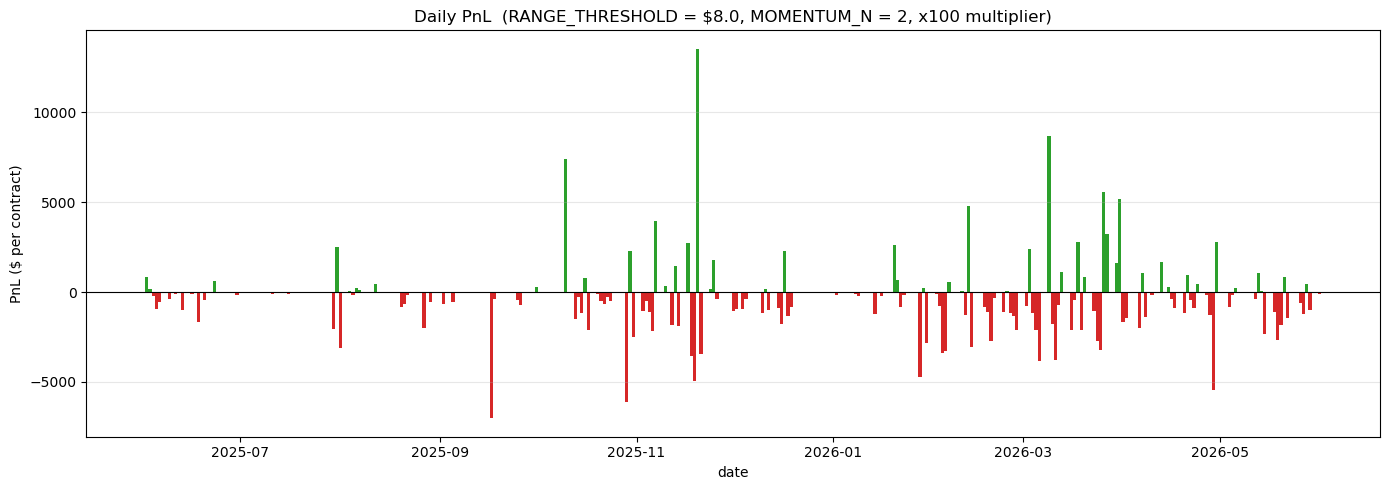

In [7]:
daily = (results.groupby("date")["pnl_contract"].sum()
         .rename("pnl").reset_index().sort_values("date"))
daily["date"] = pd.to_datetime(daily["date"])

fig, ax = plt.subplots(figsize=(14, 5))
colors = np.where(daily["pnl"] >= 0, "#2ca02c", "#d62728")
ax.bar(daily["date"], daily["pnl"], color=colors, width=1.0)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Daily PnL  (RANGE_THRESHOLD = ${RANGE_THRESHOLD}, MOMENTUM_N = {MOMENTUM_N}, "
             f"x{CONTRACT_MULTIPLIER} multiplier)")
ax.set_xlabel("date")
ax.set_ylabel("PnL ($ per contract)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Visualization — cumulative total PnL

A different view: the running equity curve across every trade in time order.

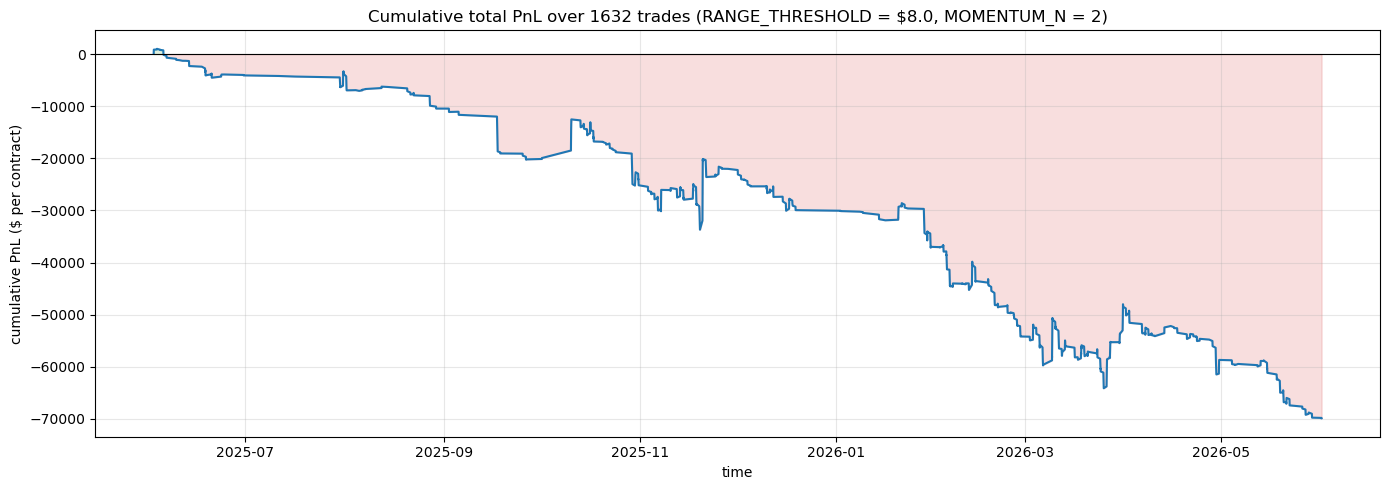

final cumulative PnL: -69,864 ($-698.64 per share)


In [8]:
cum = results.copy()
cum["cum_pnl"] = cum["pnl_contract"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cum["timestamp"], cum["cum_pnl"], color="#1f77b4", lw=1.5)
ax.fill_between(cum["timestamp"], cum["cum_pnl"], 0,
                where=cum["cum_pnl"] >= 0, color="#2ca02c", alpha=0.15)
ax.fill_between(cum["timestamp"], cum["cum_pnl"], 0,
                where=cum["cum_pnl"] < 0, color="#d62728", alpha=0.15)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Cumulative total PnL over {len(cum)} trades "
             f"(RANGE_THRESHOLD = ${RANGE_THRESHOLD}, MOMENTUM_N = {MOMENTUM_N})")
ax.set_xlabel("time")
ax.set_ylabel("cumulative PnL ($ per contract)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"final cumulative PnL: {cum['cum_pnl'].iloc[-1]:+,.0f} "
      f"(${results['pnl'].sum():+.2f} per share)")
